# BrandRadar — Asset Radar Interpretation Notebook

Este cuaderno permite subir un asset visual y generar una interpretación inicial en forma de radar.

## Objetivo

Analizar una imagen individual con 5 ejes:

1. Visual Load
2. Conversion Intent
3. Language Stress
4. Layout Complexity
5. Focus Clarity

Este modelo es heurístico: no pretende ser una verdad científica final, sino una primera capa interpretable para BrandRadar.

In [ ]:
# Instalar OCR opcional si se usa en Colab
# En algunos entornos puede requerir instalación adicional de tesseract del sistema.
# Para este notebook, OCR es opcional: si falla, el análisis continúa.

import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps, ImageStat, ImageFilter
from google.colab import files

!apt-get update -qq
!apt-get install -y tesseract-ocr
!pip install pytesseract
!apt-get install -y tesseract-ocr-spa


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 8 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr-spa is already the newest version (1:4.00~git30-7274cfa-1.1).
0 upgraded, 0 newly installed, 0 to remove and 8 not upgraded.


## 1. Upload del asset

Saving cartel-festival-estereo-picnic.jpg to cartel-festival-estereo-picnic.jpg
Loaded: cartel-festival-estereo-picnic.jpg
Size: (800, 1000)


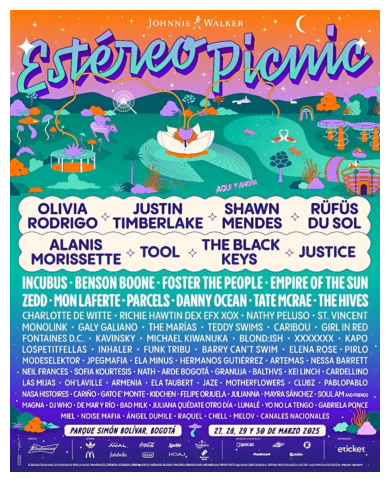

In [ ]:
uploaded = files.upload()

image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB")

print("Loaded:", image_path)
print("Size:", image.size)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.show()

## 2. Funciones auxiliares

In [ ]:
def clamp01(value):
    return max(0.0, min(1.0, float(value)))

def normalize(value, min_value, max_value):
    if max_value == min_value:
        return 0.0
    return clamp01((value - min_value) / (max_value - min_value))

def image_area(img):
    w, h = img.size
    return w * h

## 3. Extracción de features simples

Estas señales se calculan directamente desde la imagen:

- tamaño
- peso de archivo
- edge density
- contrast score
- saturation score
- estimated whitespace
- estimated region count
- dominant region proxy
- text/promo proxies simples por OCR opcional

No estamos usando object detection.

In [ ]:
def compute_basic_image_features(img, path):
    w, h = img.size
    area = w * h
    file_size_mb = os.path.getsize(path) / (1024 * 1024)

    gray = ImageOps.grayscale(img)

    # Contraste simple: desviación estándar de luminancia
    stat = ImageStat.Stat(gray)
    contrast_score = clamp01(stat.stddev[0] / 90)

    # Bordes aproximados con filtro FIND_EDGES
    edges = gray.filter(ImageFilter.FIND_EDGES)
    edge_arr = np.asarray(edges).astype(float) / 255.0
    edge_density = clamp01(edge_arr.mean() * 4)

    # Saturación promedio en HSV
    hsv = img.convert("HSV")
    hsv_arr = np.asarray(hsv).astype(float)
    saturation_score = clamp01(hsv_arr[:, :, 1].mean() / 255)

    # Whitespace estimado: pixeles muy claros o muy oscuros de baja textura
    gray_arr = np.asarray(gray).astype(float) / 255.0
    bright_space = gray_arr > 0.92
    dark_space = gray_arr < 0.06
    low_edge = edge_arr < 0.08
    whitespace_ratio = clamp01(((bright_space | dark_space) & low_edge).mean())

    # Region count proxy: grid de celdas con actividad visual alta
    grid_n = 6
    cell_scores = []
    for gy in range(grid_n):
        for gx in range(grid_n):
            y0 = int(gy * h / grid_n)
            y1 = int((gy + 1) * h / grid_n)
            x0 = int(gx * w / grid_n)
            x1 = int((gx + 1) * w / grid_n)
            cell_edge = edge_arr[y0:y1, x0:x1].mean()
            cell_contrast = gray_arr[y0:y1, x0:x1].std()
            cell_scores.append(cell_edge + cell_contrast)

    cell_scores = np.array(cell_scores)
    active_cells = cell_scores > np.percentile(cell_scores, 65)
    estimated_region_count = int(active_cells.sum())

    # Dominancia proxy: peso de la celda más activa contra el total
    dominance_proxy = clamp01(cell_scores.max() / (cell_scores.sum() + 1e-6) * 4)

    return {
        "width": w,
        "height": h,
        "area": area,
        "file_size_mb": file_size_mb,
        "aspect_ratio": w / h,
        "contrast_score": contrast_score,
        "edge_density": edge_density,
        "saturation_score": saturation_score,
        "whitespace_ratio": whitespace_ratio,
        "estimated_region_count": estimated_region_count,
        "dominance_proxy": dominance_proxy,
    }

features = compute_basic_image_features(image, image_path)
features

{'width': 800,
 'height': 1000,
 'area': 800000,
 'file_size_mb': 0.22494029998779297,
 'aspect_ratio': 0.8,
 'contrast_score': 0.7468304604998324,
 'edge_density': 0.5506671764705879,
 'saturation_score': 0.5900128921568627,
 'whitespace_ratio': 0.09672875,
 'estimated_region_count': 13,
 'dominance_proxy': 0.1371580222635765}

## 4. OCR opcional y proxies comerciales

Este bloque intenta usar `pytesseract`. Si no está disponible, continúa sin OCR.

Conversion Intent y Language Stress pueden mejorar mucho si OCR está disponible.

In [ ]:
# OCR opcional para extraer texto del asset.
# Si Colab no tiene Tesseract instalado, el notebook sigue funcionando.

import re

def try_ocr_text(img):
    try:
        import pytesseract
        text = pytesseract.image_to_string(img)
        return text or ""
    except Exception as e:
        print("OCR unavailable. Continuing without OCR.")
        print("Reason:", e)
        return ""

ocr_text = try_ocr_text(image)

print("OCR text preview:")
print(ocr_text[:1000] if ocr_text.strip() else "[No OCR text detected]")

promo_patterns = [
    r"sale", r"off", r"discount", r"promo", r"offer", r"deal",
    r"buy", r"shop", r"now", r"limited", r"save",
    r"precio", r"oferta", r"descuento", r"compra", r"ahora",
    r"%", r"\$", r"\d+x", r"free"
]

def compute_text_features(text):
    clean = text.strip()
    words = re.findall(r"\b\w+\b", clean)
    numbers = re.findall(r"\d+", clean)

    promo_hits = sum(
        len(re.findall(pattern, clean, flags=re.IGNORECASE))
        for pattern in promo_patterns
    )

    uppercase_words = [
        word for word in words
        if len(word) > 2 and word.isupper()
    ]

    return {
        "ocr_available": bool(clean),
        "word_count": len(words),
        "number_count": len(numbers),
        "promo_token_count": promo_hits,
        "uppercase_ratio": 0 if not words else len(uppercase_words) / len(words),
    }

text_features = compute_text_features(ocr_text)
text_features


OCR text preview:
 

OLIVIA. JUSTIN, SHAWN . RUFUS
RODRIGO * TIMBERLAKE “ MENDES ~ DUSOL

ALANIS g > TOOL « , THE BLACK

MORISSETT KEys  ~ JUSTICE

CNS TaN ESO Sa Te Ta ky
eT CRS UGC rT sa tas)

CHARLOTTE DE WITTE - RICHIE HAWTIN DEX EFX XOX + NATHY PELUSO - ST. VINCENT
MONOLINK + GALY GALIANO + THE MARIAS - TEDDY SWIMS - CARIBOU - GIRLIN RED
FONTAINES D.C. + KAVINSKY + MICHAEL KIWANUKA + BLOND:ISH + XXXXXXX + KAPO
LOSPETITFELLAS - INHALER - FUNK TRIBU - BARRY CAN'T SWIM - ELENAROSE - PIRLO ~

~ MODESELEKTOR - JPEGMAFIA - ELA MINUS - HERMANOS GUTIERREZ - ARTEMAS - NESSA BARRETT
+ NEIL FRANCES - SOFIA KOURTESIS - NATH - ARDE BOGOTA - GRANUJA - BALTHVS - KEI INCH CARDELLINO -

LAS MIJAS + OH’LAVILLE - ARMENIA - ELA TAUBERT - JAZE- MOTHERFLOWERS ~- CLUBZ - PABLOPABLO

SISter Ueno (nes este USEC UN EMC Ue Zager

ae

t= Damon Oa Ua Wort (ol t moL0] Vie aay (else tT Ke MS tele aS

PARQUE SiMOW BOLIVAR, BOGOTA « 27, 28, 29 vo 38 DE MARZO 2625 cd

oN MM Oe ACSA oer WV es LW Vell so) (40) col] 

{'ocr_available': True,
 'word_count': 162,
 'number_count': 7,
 'promo_token_count': 0,
 'uppercase_ratio': 0.5864197530864198}

## 5. Cálculo de scores del radar

Usamos solo 5 ejes:

- Visual Load
- Conversion Intent
- Language Stress
- Layout Complexity
- Focus Clarity

In [ ]:
def compute_asset_radar_scores(features, text_features):
    region_pressure = clamp01(features["estimated_region_count"] / 24)
    inverse_whitespace = clamp01(1 - features["whitespace_ratio"])
    dominance = clamp01(features["dominance_proxy"])

    word_pressure = clamp01(text_features["word_count"] / 80)
    number_pressure = clamp01(text_features["number_count"] / 15)
    promo_pressure = clamp01(text_features["promo_token_count"] / 10)
    uppercase_pressure = clamp01(text_features["uppercase_ratio"] * 2)

    visual_load = clamp01(
        0.26 * features["edge_density"] +
        0.20 * features["contrast_score"] +
        0.18 * features["saturation_score"] +
        0.18 * region_pressure +
        0.18 * inverse_whitespace
    )

    conversion_intent = clamp01(
        0.38 * promo_pressure +
        0.24 * number_pressure +
        0.16 * uppercase_pressure +
        0.12 * features["contrast_score"] +
        0.10 * dominance
    )

    language_stress = clamp01(
        0.40 * word_pressure +
        0.25 * promo_pressure +
        0.20 * number_pressure +
        0.15 * uppercase_pressure
    )

    layout_complexity = clamp01(
        0.40 * region_pressure +
        0.22 * features["edge_density"] +
        0.18 * inverse_whitespace +
        0.20 * (1 - dominance)
    )

    focus_clarity = clamp01(
        0.42 * dominance +
        0.24 * features["contrast_score"] +
        0.20 * features["whitespace_ratio"] +
        0.14 * (1 - region_pressure)
    )

    return {
        "Visual Load": visual_load,
        "Conversion Intent": conversion_intent,
        "Language Stress": language_stress,
        "Layout Complexity": layout_complexity,
        "Focus Clarity": focus_clarity,
    }

radar_scores = compute_asset_radar_scores(features, text_features)
radar_scores

{'Visual Load': 0.6588307035705546,
 'Conversion Intent': 0.37533545748633756,
 'Language Stress': 0.6433333333333333,
 'Layout Complexity': 0.6729706660374808,
 'Focus Clarity': 0.3203580965373286}

## 6. Clasificación macroterritorial

Usamos:

- X = Conversion Intent
- Y = Visual Load

Territorios:

- Low Intent + Low Load → Atmospheric Minimal
- High Intent + Low Load → Precision Conversion
- Low Intent + High Load → Narrative Density
- High Intent + High Load → Hypercommerce

In [ ]:
def classify_macroterritory(scores, threshold=0.5):
    x = scores["Conversion Intent"]
    y = scores["Visual Load"]

    if x < threshold and y < threshold:
        return "Atmospheric Minimal"
    if x >= threshold and y < threshold:
        return "Precision Conversion"
    if x < threshold and y >= threshold:
        return "Narrative Density"
    return "Hypercommerce"

territory = classify_macroterritory(radar_scores)
territory

'Narrative Density'

## 7. Radar chart con Matplotlib

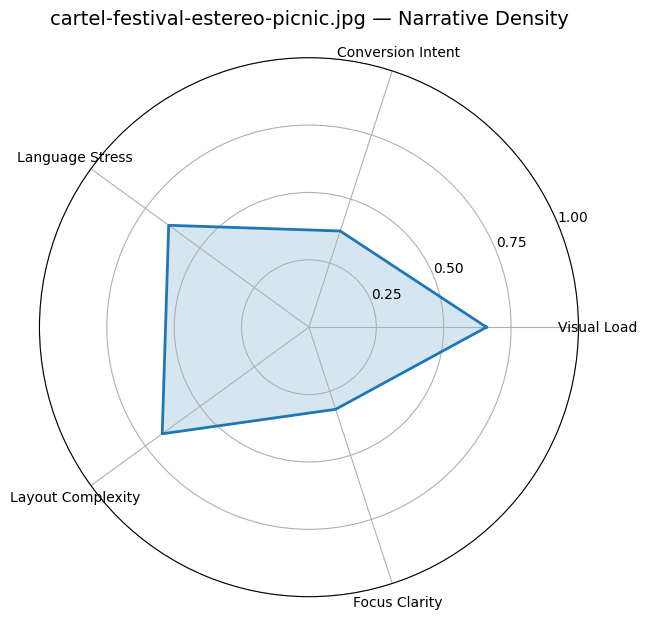

In [ ]:
def plot_radar(scores, title="BrandRadar Asset Radar"):
    labels = list(scores.keys())
    values = list(scores.values())

    values += values[:1]
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    fig = plt.figure(figsize=(7, 7))
    ax = plt.subplot(111, polar=True)

    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.18)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_title(title, pad=24, fontsize=14)

    plt.show()

plot_radar(radar_scores, f"{image_path} — {territory}")

## 8. Visual Behavior Map

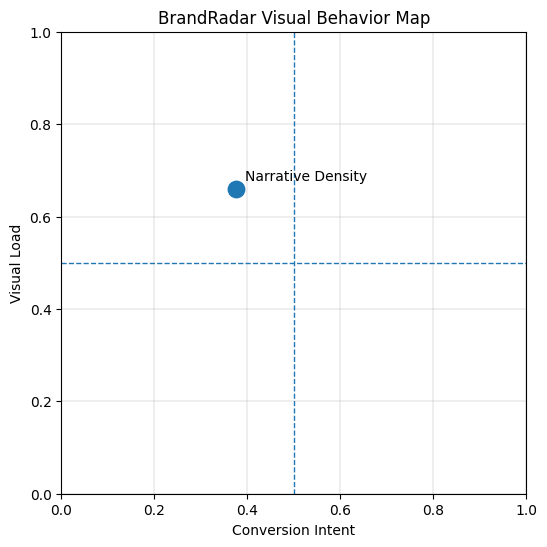

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter([radar_scores["Conversion Intent"]], [radar_scores["Visual Load"]], s=140)
plt.axvline(0.5, linestyle="--", linewidth=1)
plt.axhline(0.5, linestyle="--", linewidth=1)

plt.text(radar_scores["Conversion Intent"] + 0.02, radar_scores["Visual Load"] + 0.02, territory)

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("Conversion Intent")
plt.ylabel("Visual Load")
plt.title("BrandRadar Visual Behavior Map")
plt.grid(True, linewidth=0.3)
plt.show()

## 9. Lectura automática

In [ ]:
def generate_asset_reading(scores, territory):
    notes = []

    if scores["Visual Load"] >= 0.65:
        notes.append("high visual load")
    elif scores["Visual Load"] <= 0.35:
        notes.append("low visual load")

    if scores["Conversion Intent"] >= 0.65:
        notes.append("strong conversion pressure")
    elif scores["Conversion Intent"] <= 0.35:
        notes.append("low conversion pressure")

    if scores["Language Stress"] >= 0.60:
        notes.append("high language stress")

    if scores["Layout Complexity"] >= 0.60:
        notes.append("complex layout structure")

    if scores["Focus Clarity"] >= 0.65:
        notes.append("clear primary focus")
    elif scores["Focus Clarity"] <= 0.35:
        notes.append("diffuse or weak focus clarity")

    if not notes:
        notes.append("balanced visual behavior")

    return f"This asset is classified as {territory}. It shows " + ", ".join(notes) + "."

reading = generate_asset_reading(radar_scores, territory)
reading

'This asset is classified as Narrative Density. It shows high visual load, high language stress, complex layout structure, diffuse or weak focus clarity.'

## 10. Resumen tabular

In [ ]:
summary = pd.DataFrame([
    {"Metric": key, "Score": round(value, 3)}
    for key, value in radar_scores.items()
])

summary.loc[len(summary)] = {"Metric": "Territory", "Score": territory}
summary.loc[len(summary)] = {"Metric": "Reading", "Score": reading}

summary

,Metric,Score
0,Visual Load,0.659
1,Conversion Intent,0.375
2,Language Stress,0.643
3,Layout Complexity,0.673
4,Focus Clarity,0.32
5,Territory,Narrative Density
6,Reading,This asset is classified as Narrative Density....
